# NFL Injury Prediction — Model Analysis Notebook

This notebook provides a structured analysis of the injury prediction model covering:
1. **Data Load & Cleaning** — pull training data and environmental features
2. **Input Sensitivity** — does the model react meaningfully to different severity/status inputs?
3. **Feature Importance** — what does the trained model actually rely on?
4. **Probability Calibration** — are the predicted probabilities trustworthy?
5. **Feature Count Tradeoff** — how many features do we actually need?
6. **Environmental & Demographic Correlations** — weather, age, experience, surface vs injury patterns
7. **Age & Experience Risk** — numeric factors with highest effect sizes
8. **Executive Summary**

In [50]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, f_oneway
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder

import sys, os
sys.path.insert(0, '/Users/tysayball-wimmer/Documents/Current_Work/Capstone')
from injuryAPI import many, get_advanced_model_bundle, _build_model_base_rows, _engineer_model_dataframe

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print("Imports OK")
print("Loading model bundle...")
bundle = get_advanced_model_bundle()
print(f"Model ready: {bundle.get('ready')}  |  rows: {bundle.get('dataset',{}).get('row_count')}  |  features: {bundle.get('dataset',{}).get('feature_count')}")

Imports OK
Loading model bundle...
Model ready: True  |  rows: 98518  |  features: 43


## 1. Load Training Data + Environmental Features

Pull all injury records joined with game environment (surface, roof, temp, wind, weather) and player demographics (age, experience, position).

In [51]:
from nfl_data import config
import pymysql

conn = pymysql.connect(
    host=config.host, port=int(config.port), user=config.user,
    passwd=config.passwd, db=config.db, connect_timeout=10, read_timeout=120
)

sql = """
SELECT
    ir.gsis_id, ir.season, ir.week, ir.game_type, ir.team,
    ir.full_name,
    COALESCE(NULLIF(TRIM(ir.position),''), NULLIF(TRIM(p.position),'')) AS position,
    COALESCE(NULLIF(TRIM(p.position_group),''), NULLIF(TRIM(ir.position),'')) AS position_group,
    ir.severity, ir.report_status, ir.practice_status,
    ir.injury_type, ir.injury_detail, ir.on_ir,
    p.birth_date, p.years_of_experience, p.draft_round,
    g.surface, g.roof, g.stadium, g.avg_temp AS temp, g.avg_wind AS wind, g.weather_raw
FROM injuryReport ir
LEFT JOIN players p ON p.gsis_id = ir.gsis_id
LEFT JOIN (
    SELECT
        season, season_type, week, home_team, away_team,
        MIN(stadium) AS stadium,
        MIN(surface) AS surface,
        MAX(CASE WHEN LOWER(TRIM(COALESCE(roof,''))) IN ('dome','closed') THEN 'dome' ELSE COALESCE(NULLIF(TRIM(roof),''), 'open') END) AS roof,
        AVG(CAST(NULLIF(TRIM(temp),'') AS DECIMAL(6,2))) AS avg_temp,
        AVG(CAST(NULLIF(TRIM(wind),'') AS DECIMAL(6,2))) AS avg_wind,
        MIN(weather) AS weather_raw
    FROM pbp
    WHERE season IS NOT NULL AND season_type IS NOT NULL AND week IS NOT NULL
      AND home_team IS NOT NULL AND away_team IS NOT NULL
    GROUP BY season, season_type, week, home_team, away_team
) g ON g.season = ir.season AND g.season_type = ir.game_type
     AND g.week = ir.week
     AND (g.home_team = ir.team OR g.away_team = ir.team)
WHERE ir.season >= 2011 AND ir.game_type IS NOT NULL
"""

try:
    df_env = pd.read_sql(sql, conn)
finally:
    conn.close()

# Add compatibility placeholders expected by later analysis code.
for col in ['games_missed_next_2', 'games_missed_next_3', 'games_missed_next_4']:
    if col not in df_env.columns:
        df_env[col] = np.nan

# Derive numeric fields
df_env['age'] = df_env['birth_date'].apply(
    lambda d: (pd.Timestamp('2023-09-01') - pd.to_datetime(d, errors='coerce')).days / 365.25
    if pd.notna(d) else np.nan
)

def parse_humidity(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r'(\d+)\s*%', text)
    return float(m.group(1)) if m else np.nan

df_env['humidity'] = df_env['weather_raw'].apply(parse_humidity)

# Standardise unknown tokens
UNKNOWN = {'unknown', 'none', 'n/a', 'na', '', 'nan', 'null', 'not specified'}

def clean_cat(s):
    if pd.isna(s):
        return np.nan
    v = str(s).strip()
    return np.nan if v.lower() in UNKNOWN else v

for col in ['severity', 'report_status', 'practice_status', 'injury_type', 'injury_detail', 'surface', 'roof', 'position_group', 'position']:
    df_env[col] = df_env[col].apply(clean_cat)

print(f"Loaded {len(df_env):,} rows")
print(f"Temp coverage: {df_env['temp'].notna().mean():.0%} | Humidity: {df_env['humidity'].notna().mean():.0%} | Age: {df_env['age'].notna().mean():.0%}")
df_env.head(3)

Loaded 75,372 rows
Temp coverage: 65% | Humidity: 85% | Age: 100%


,gsis_id,season,week,game_type,team,full_name,position,position_group,severity,report_status,practice_status,injury_type,injury_detail,on_ir,birth_date,years_of_experience,draft_round,surface,roof,stadium,temp,wind,weather_raw,games_missed_next_2,games_missed_next_3,games_missed_next_4,age,humidity
0,00-0032889,2018,11,REG,DET,A'Shawn Robinson,DT,DL,NaN,Out,Did Not Participate In Practice,Ankle,Ankle,None,1995-03-21,10,2.0,fieldturf,dome,Ford Field,NaN,NaN,"Temp: 69° F, Humidity: 70%, Wind: mph",NaN,NaN,NaN,28.449008,70.0
1,00-0032889,2018,12,REG,DET,A'Shawn Robinson,DT,DL,NaN,Questionable,Limited Participation in Practice,Ankle,Ankle,None,1995-03-21,10,2.0,fieldturf,dome,Ford Field,NaN,NaN,"Temp: 68° F, Humidity: 70%, Wind: mph",NaN,NaN,NaN,28.449008,70.0
2,00-0032889,2019,10,REG,DET,A'Shawn Robinson,DT,DL,NaN,Questionable,Full Participation in Practice,Ankle,Ankle,None,1995-03-21,10,2.0,grass,outdoors,Soldier Field,40.0,12.0,"overcast Temp: 40° F, Humidity: 80%, Wind: N 1...",NaN,NaN,NaN,28.449008,80.0


## 1B. Return-To-Play Label Construction (Events + Injury + Snap Counts)

Goal:
- Use `events` + `injuryReport` to determine when an injury first occurred.
- Use `snap_counts` to find the **first next game the player appeared** after that injury date.
- Build `return_days` and `returned_within_28` labels for machine learning.

Modeling choice:
- Use a **Random Forest Classifier** for feature-finding (not logistic/linear regression).

In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1) Events: injury occurrence anchor
sql_events = """
SELECT
    injuryId,
    playerName,
    first_report_date,
    injury_type AS event_injury_type,
    injury_detail AS event_injury_detail
FROM events
WHERE first_report_date IS NOT NULL
"""
df_events = pd.read_sql(sql_events, pymysql.connect(
    host=config.host, port=int(config.port), user=config.user,
    passwd=config.passwd, db=config.db, connect_timeout=10, read_timeout=120
))

# 2) First injury-report row per injuryId (severity/status/features at onset)
sql_onset = """
SELECT
    ir.injuryId,
    ir.transactionDate,
    ir.full_name,
    ir.team,
    ir.season,
    ir.week,
    ir.game_type,
    ir.severity,
    ir.report_status,
    ir.practice_status,
    ir.position,
    ir.on_ir,
    p.years_of_experience,
    p.birth_date,
    p.position_group
FROM injuryReport ir
LEFT JOIN players p ON p.gsis_id = ir.gsis_id
JOIN (
    SELECT injuryId, MIN(transactionDate) AS first_txn
    FROM injuryReport
    GROUP BY injuryId
) first_ir
  ON ir.injuryId = first_ir.injuryId
 AND ir.transactionDate = first_ir.first_txn
"""
df_onset = pd.read_sql(sql_onset, pymysql.connect(
    host=config.host, port=int(config.port), user=config.user,
    passwd=config.passwd, db=config.db, connect_timeout=10, read_timeout=120
))

# Deduplicate in case of ties on first transactionDate
df_onset = df_onset.sort_values(['injuryId', 'transactionDate']).drop_duplicates('injuryId', keep='first')

# 3) Snap counts with game dates from pbp
sql_snaps = """
SELECT
    sc.player_name,
    sc.team,
    sc.season,
    sc.week,
    sc.game_type,
    sc.did_play,
    sc.total_snaps,
    g.game_date
FROM snap_counts sc
LEFT JOIN (
    SELECT gameId, MIN(gameDate) AS game_date
    FROM pbp
    WHERE gameId IS NOT NULL AND gameDate IS NOT NULL
    GROUP BY gameId
) g ON g.gameId = sc.game_id
WHERE sc.did_play = 1
"""
df_snaps = pd.read_sql(sql_snaps, pymysql.connect(
    host=config.host, port=int(config.port), user=config.user,
    passwd=config.passwd, db=config.db, connect_timeout=10, read_timeout=120
))

# ---- Build injury-onset table ----
df_events['first_report_date'] = pd.to_datetime(df_events['first_report_date'], errors='coerce')
df_onset['transactionDate'] = pd.to_datetime(df_onset['transactionDate'], errors='coerce')
df_onset['birth_date'] = pd.to_datetime(df_onset['birth_date'], errors='coerce')
df_snaps['game_date'] = pd.to_datetime(df_snaps['game_date'], errors='coerce')

def norm_name(s):
    if pd.isna(s):
        return ''
    return re.sub(r'[^a-z0-9]', '', str(s).lower())

df_events['player_key'] = df_events['playerName'].apply(norm_name)
df_onset['player_key'] = df_onset['full_name'].apply(norm_name)
df_snaps['player_key'] = df_snaps['player_name'].apply(norm_name)

# Merge events with onset row/features by injuryId
rtp = df_events.merge(df_onset, on='injuryId', how='left', suffixes=('', '_onset'))

# Injury occurrence date priority: events first_report_date, fallback onset transaction date
rtp['injury_date'] = rtp['first_report_date'].fillna(rtp['transactionDate'])
rtp = rtp[rtp['injury_date'].notna() & (rtp['player_key'] != '')].copy()

# Attach age at injury
rtp['age_at_injury'] = (rtp['injury_date'] - rtp['birth_date']).dt.days / 365.25

# ---- Find next snap appearance after injury date (per-player asof merge) ----
snaps_sorted = df_snaps[df_snaps['game_date'].notna()].copy()

merged_parts = []
for pkey, grp in rtp.groupby('player_key', sort=False):
    left = grp.sort_values('injury_date').copy()
    right = snaps_sorted.loc[snaps_sorted['player_key'] == pkey, ['game_date', 'season', 'week', 'team', 'total_snaps']].sort_values('game_date').copy()

    if right.empty:
        left['game_date'] = pd.NaT
        left['season_snap'] = np.nan
        left['week_snap'] = np.nan
        left['team_snap'] = np.nan
        left['total_snaps'] = np.nan
        merged_parts.append(left)
        continue

    m = pd.merge_asof(
        left,
        right,
        left_on='injury_date',
        right_on='game_date',
        direction='forward',
        suffixes=('', '_snap')
    )
    merged_parts.append(m)

rtp_next = pd.concat(merged_parts, ignore_index=True)

rtp_next['returned'] = rtp_next['game_date'].notna().astype(int)
rtp_next['return_days'] = (rtp_next['game_date'] - rtp_next['injury_date']).dt.days
rtp_next['returned_within_28'] = ((rtp_next['return_days'] <= 28) & rtp_next['return_days'].notna()).astype(int)

# Keep reasonable window for supervised target quality
rtp_model = rtp_next[(rtp_next['return_days'].isna()) | ((rtp_next['return_days'] >= 0) & (rtp_next['return_days'] <= 180))].copy()

print(f"RTP rows: {len(rtp_model):,}")
print(f"Returned at any point: {rtp_model['returned'].mean():.1%}")
print(f"Returned within 28 days: {rtp_model['returned_within_28'].mean():.1%}")
rtp_model[['injuryId','playerName','injury_date','game_date','return_days','returned_within_28']].head(10)

RTP rows: 41,413
Returned at any point: 77.1%
Returned within 28 days: 68.0%


,injuryId,playerName,injury_date,game_date,return_days,returned_within_28
0,11_Unknown_1.0,11,2024-12-28,NaT,NaN,0
1,5_Unknown_1.0,5,2021-07-28,NaT,NaN,0
2,A.J. Barner_Shoulder_1.0,A.J. Barner,2024-12-20,2024-12-22,2.0,1
3,A.J. Bouye_Knee_1.0,A.J. Bouye,2013-09-07,2013-09-09,2.0,1
6,A.J. Bouye_Shoulder_1.0,A.J. Bouye,2014-09-05,2014-09-07,2.0,1
7,A.J. Bouye_Groin_1.0,A.J. Bouye,2014-09-26,2014-10-09,13.0,1
8,A.J. Bouye_Illness_1.0,A.J. Bouye,2015-10-16,2015-10-18,2.0,1
9,A.J. Bouye_Concussion_1.0,A.J. Bouye,2015-11-27,2015-12-06,9.0,1
10,A.J. Bouye_Knee_2.0,A.J. Bouye,2016-01-01,2016-01-03,2.0,1
11,A.J. Bouye_Shoulder_2.0,A.J. Bouye,2016-09-21,2016-09-22,1.0,1


In [ ]:
# Persist injury return labels to MySQL so return date is stored in the database.
# We use a dedicated table to avoid mutating source ingestion tables.

persist_df = rtp_next[[
    'injuryId', 'playerName', 'injury_date', 'game_date',
    'return_days', 'returned', 'returned_within_28'
]].copy()

persist_df = persist_df.rename(columns={
    'injuryId': 'injury_id',
    'playerName': 'player_name',
    'game_date': 'return_date'
})

persist_df['injury_date'] = pd.to_datetime(persist_df['injury_date'], errors='coerce').dt.date
persist_df['return_date'] = pd.to_datetime(persist_df['return_date'], errors='coerce').dt.date
persist_df['return_days'] = pd.to_numeric(persist_df['return_days'], errors='coerce')
persist_df['returned'] = pd.to_numeric(persist_df['returned'], errors='coerce').fillna(0).astype(int)
persist_df['returned_within_28'] = pd.to_numeric(persist_df['returned_within_28'], errors='coerce').fillna(0).astype(int)

# Keep one row per injury_id for deterministic upsert.
persist_df = (
    persist_df
    .sort_values(['injury_id', 'injury_date', 'return_date'], na_position='last')
    .drop_duplicates(subset=['injury_id'], keep='first')
)
persist_df = persist_df[persist_df['injury_id'].notna() & persist_df['injury_date'].notna()].copy()

rows_to_write = [
    (
        int(r.injury_id),
        None if pd.isna(r.player_name) else str(r.player_name)[:120],
        r.injury_date,
        r.return_date if pd.notna(r.return_date) else None,
        int(r.return_days) if pd.notna(r.return_days) else None,
        int(r.returned),
        int(r.returned_within_28),
    )
    for r in persist_df.itertuples(index=False)
]

conn_write = pymysql.connect(
    host=config.host,
    port=int(config.port),
    user=config.user,
    passwd=config.passwd,
    db=config.db,
    connect_timeout=10,
    read_timeout=120,
    write_timeout=120,
    autocommit=False,
)

try:
    with conn_write.cursor() as cur:
        cur.execute('''
            CREATE TABLE IF NOT EXISTS injury_return_labels (
                injury_id BIGINT NOT NULL,
                player_name VARCHAR(120) NULL,
                injury_date DATE NOT NULL,
                return_date DATE NULL,
                return_days INT NULL,
                returned TINYINT(1) NOT NULL DEFAULT 0,
                returned_within_28 TINYINT(1) NOT NULL DEFAULT 0,
                source VARCHAR(32) NOT NULL DEFAULT 'ml_predict',
                updated_at TIMESTAMP NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
                PRIMARY KEY (injury_id),
                KEY idx_player_injury_date (player_name, injury_date),
                KEY idx_return_date (return_date)
            ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
        ''')

        cur.executemany('''
            INSERT INTO injury_return_labels (
                injury_id, player_name, injury_date, return_date,
                return_days, returned, returned_within_28, source
            ) VALUES (%s, %s, %s, %s, %s, %s, %s, 'ml_predict')
            ON DUPLICATE KEY UPDATE
                player_name = VALUES(player_name),
                injury_date = VALUES(injury_date),
                return_date = VALUES(return_date),
                return_days = VALUES(return_days),
                returned = VALUES(returned),
                returned_within_28 = VALUES(returned_within_28),
                source = 'ml_predict';
        ''', rows_to_write)

    conn_write.commit()

    verify_sql = '''
        SELECT
            COUNT(*) AS row_count,
            SUM(CASE WHEN returned = 1 THEN 1 ELSE 0 END) AS returned_count,
            SUM(CASE WHEN returned_within_28 = 1 THEN 1 ELSE 0 END) AS returned_within_28_count,
            MIN(injury_date) AS min_injury_date,
            MAX(injury_date) AS max_injury_date
        FROM injury_return_labels
        WHERE source = 'ml_predict'
    '''
    verify_df = pd.read_sql(verify_sql, conn_write)

    print(f"Upserted {len(rows_to_write):,} injury return rows into injury_return_labels")
    display(verify_df)

except Exception:
    conn_write.rollback()
    raise
finally:
    conn_write.close()

In [71]:
# Persist injury return labels to MySQL so return date is stored in the database.
# Dedicated table keeps source ingestion tables unchanged.

persist_df = rtp_next[[
    'injuryId', 'playerName', 'injury_date', 'game_date',
    'return_days', 'returned', 'returned_within_28'
]].copy()

persist_df = persist_df.rename(columns={
    'injuryId': 'injury_id',
    'playerName': 'player_name',
    'game_date': 'return_date'
})

persist_df['injury_id'] = persist_df['injury_id'].astype(str).str.strip()
persist_df['injury_date'] = pd.to_datetime(persist_df['injury_date'], errors='coerce').dt.date
persist_df['return_date'] = pd.to_datetime(persist_df['return_date'], errors='coerce').dt.date
persist_df['return_days'] = pd.to_numeric(persist_df['return_days'], errors='coerce')
persist_df['returned'] = pd.to_numeric(persist_df['returned'], errors='coerce').fillna(0).astype(int)
persist_df['returned_within_28'] = pd.to_numeric(persist_df['returned_within_28'], errors='coerce').fillna(0).astype(int)

persist_df = (
    persist_df
    .sort_values(['injury_id', 'injury_date', 'return_date'], na_position='last')
    .drop_duplicates(subset=['injury_id'], keep='first')
)
persist_df = persist_df[(persist_df['injury_id'] != '') & persist_df['injury_date'].notna()].copy()

rows_to_write = [
    (
        str(r.injury_id)[:190],
        None if pd.isna(r.player_name) else str(r.player_name)[:120],
        r.injury_date,
        r.return_date if pd.notna(r.return_date) else None,
        int(r.return_days) if pd.notna(r.return_days) else None,
        int(r.returned),
        int(r.returned_within_28),
    )
    for r in persist_df.itertuples(index=False)
]

conn_write = pymysql.connect(
    host=config.host,
    port=int(config.port),
    user=config.user,
    passwd=config.passwd,
    db=config.db,
    connect_timeout=20,
    read_timeout=900,
    write_timeout=900,
    autocommit=False,
)

upsert_sql = '''
    INSERT INTO injury_return_labels (
        injury_id, player_name, injury_date, return_date,
        return_days, returned, returned_within_28, source
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, 'ml_predict')
    ON DUPLICATE KEY UPDATE
        player_name = VALUES(player_name),
        injury_date = VALUES(injury_date),
        return_date = VALUES(return_date),
        return_days = VALUES(return_days),
        returned = VALUES(returned),
        returned_within_28 = VALUES(returned_within_28),
        source = 'ml_predict';
'''

batch_size = 100
written = 0

try:
    with conn_write.cursor() as cur:
        cur.execute('''
            CREATE TABLE IF NOT EXISTS injury_return_labels (
                injury_id VARCHAR(190) NOT NULL,
                player_name VARCHAR(120) NULL,
                injury_date DATE NOT NULL,
                return_date DATE NULL,
                return_days INT NULL,
                returned TINYINT(1) NOT NULL DEFAULT 0,
                returned_within_28 TINYINT(1) NOT NULL DEFAULT 0,
                source VARCHAR(32) NOT NULL DEFAULT 'ml_predict',
                updated_at TIMESTAMP NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
                PRIMARY KEY (injury_id),
                KEY idx_player_injury_date (player_name, injury_date),
                KEY idx_return_date (return_date)
            ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
        ''')

    for i in range(0, len(rows_to_write), batch_size):
        chunk = rows_to_write[i:i + batch_size]
        with conn_write.cursor() as cur:
            cur.executemany(upsert_sql, chunk)
        conn_write.commit()
        written += len(chunk)

    verify_df = pd.read_sql('''
        SELECT
            COUNT(*) AS row_count,
            SUM(CASE WHEN returned = 1 THEN 1 ELSE 0 END) AS returned_count,
            SUM(CASE WHEN returned_within_28 = 1 THEN 1 ELSE 0 END) AS returned_within_28_count,
            MIN(injury_date) AS min_injury_date,
            MAX(injury_date) AS max_injury_date
        FROM injury_return_labels
        WHERE source = 'ml_predict'
    ''', conn_write)

    print(f"Upserted {written:,} injury return rows into injury_return_labels")
    display(verify_df)

except Exception:
    try:
        conn_write.rollback()
    except Exception:
        pass
    raise
finally:
    conn_write.close()

Upserted 51,260 injury return rows into injury_return_labels


,row_count,returned_count,returned_within_28_count,min_injury_date,max_injury_date
0,51260,41777.0,28145.0,2011-08-11,2026-01-23


python(48567) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


RandomForest AUC (return within 28 days): 0.9059


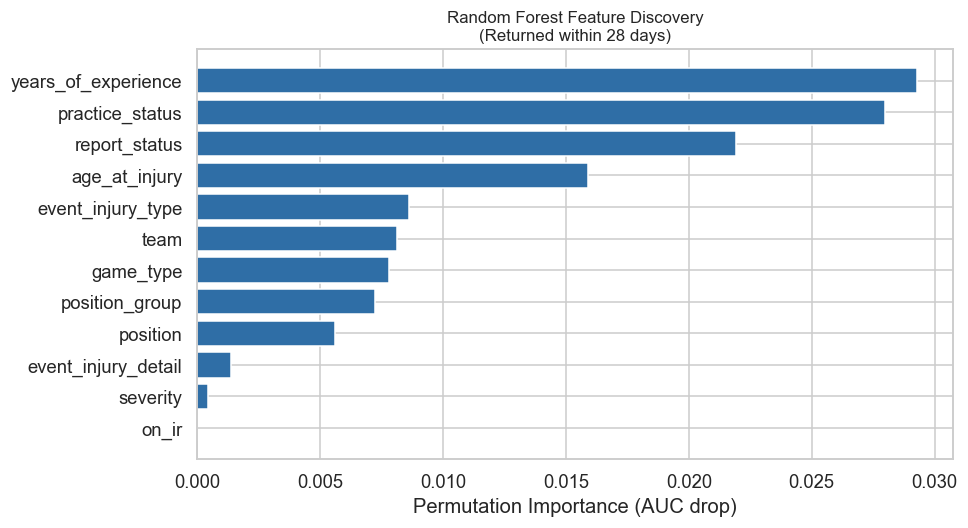


Top RandomForest features:
            feature  importance
years_of_experience    0.029275
    practice_status    0.027996
      report_status    0.021927
      age_at_injury    0.015919
  event_injury_type    0.008631
               team    0.008112
          game_type    0.007793
     position_group    0.007217
           position    0.005604
event_injury_detail    0.001366
           severity    0.000426
              on_ir    0.000000


In [47]:
# Random Forest for feature discovery on return-within-28-days
rf_features = [
    'event_injury_type', 'event_injury_detail',
    'severity', 'report_status', 'practice_status',
    'position', 'position_group', 'team', 'game_type',
    'on_ir', 'years_of_experience', 'age_at_injury'
]

target_col = 'returned_within_28'
rf_df = rtp_model.copy()

for c in rf_features:
    if c not in rf_df.columns:
        rf_df[c] = np.nan

rf_df = rf_df[rf_df[target_col].notna()].copy()
for c in rf_features:
    if rf_df[c].dtype == 'object' or str(rf_df[c].dtype).startswith('category'):
        rf_df[c] = rf_df[c].fillna('Unknown').astype(str)
    else:
        rf_df[c] = pd.to_numeric(rf_df[c], errors='coerce').fillna(-1)

X = rf_df[rf_features]
y = rf_df[target_col].astype(int)

if y.nunique() < 2:
    print('Not enough class diversity for RandomForest training (target has <2 classes).')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    cat_cols = [c for c in rf_features if X[c].dtype == 'object']
    num_cols = [c for c in rf_features if c not in cat_cols]

    pre = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', 'passthrough', num_cols),
        ]
    )

    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced_subsample'
    )

    rf_pipe = Pipeline([
        ('prep', pre),
        ('rf', rf)
    ])

    rf_pipe.fit(X_train, y_train)
    proba = rf_pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f'RandomForest AUC (return within 28 days): {auc:.4f}')

    # Permutation importance on original feature columns
    perm = permutation_importance(
        rf_pipe,
        X_test,
        y_test,
        n_repeats=8,
        random_state=42,
        scoring='roc_auc'
    )

    imp = pd.DataFrame({
        'feature': rf_features,
        'importance': perm.importances_mean
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(9, 5))
    top_imp = imp.head(12).sort_values('importance', ascending=True)
    plt.barh(top_imp['feature'], top_imp['importance'], color='#2f6ea6')
    plt.title('Random Forest Feature Discovery\n(Returned within 28 days)', fontsize=11)
    plt.xlabel('Permutation Importance (AUC drop)')
    plt.tight_layout()
    plt.savefig('static/images/rf_feature_discovery_return28.png', bbox_inches='tight', dpi=120)
    plt.show()

    print('\nTop RandomForest features:')
    print(imp.head(12).to_string(index=False))

## 2. Input Sensitivity Analysis

Does the model meaningfully respond to different severity/status/time-missed combinations? We build a grid of 18 scenarios and plot predicted play probability. A well-behaved model should show a clear gradient from serious+doubtful → mild+probable.

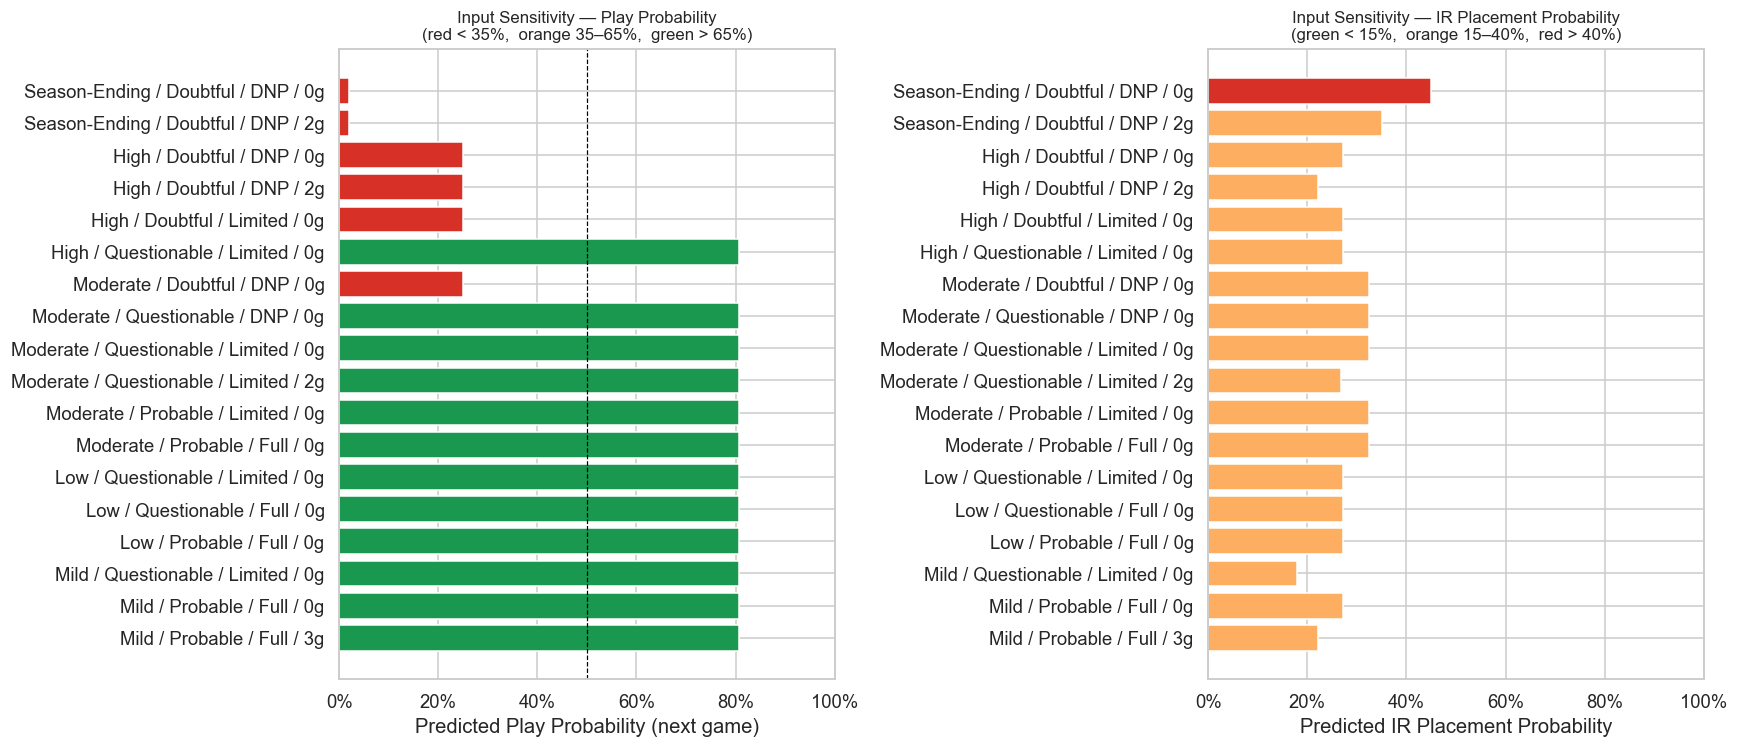

                              scenario  play_prob  ir_prob
   Season-Ending / Doubtful / DNP / 0g     0.0200   0.4500
   Season-Ending / Doubtful / DNP / 2g     0.0200   0.3500
            High / Doubtful / DNP / 0g     0.2500   0.2712
            High / Doubtful / DNP / 2g     0.2500   0.2206
        High / Doubtful / Limited / 0g     0.2500   0.2712
    High / Questionable / Limited / 0g     0.8071   0.2712
        Moderate / Doubtful / DNP / 0g     0.2500   0.3245
    Moderate / Questionable / DNP / 0g     0.8071   0.3245
Moderate / Questionable / Limited / 0g     0.8071   0.3245
Moderate / Questionable / Limited / 2g     0.8071   0.2677
    Moderate / Probable / Limited / 0g     0.8071   0.3245
       Moderate / Probable / Full / 0g     0.8071   0.3245
     Low / Questionable / Limited / 0g     0.8071   0.2712
        Low / Questionable / Full / 0g     0.8071   0.2712
            Low / Probable / Full / 0g     0.8071   0.2712
    Mild / Questionable / Limited / 0g     0.8071   0.18

In [52]:
import requests

BASE = "http://127.0.0.1:5001/api/model/predict"

scenarios = [
    # (label, severity, report_status, practice_status, time_missed)
    ("Season-Ending / Doubtful / DNP / 0g",   "Season-Ending", "Doubtful",     "Did Not Practice", 0),
    ("Season-Ending / Doubtful / DNP / 2g",   "Season-Ending", "Doubtful",     "Did Not Practice", 2),
    ("High / Doubtful / DNP / 0g",            "High",          "Doubtful",     "Did Not Practice", 0),
    ("High / Doubtful / DNP / 2g",            "High",          "Doubtful",     "Did Not Practice", 2),
    ("High / Doubtful / Limited / 0g",        "High",          "Doubtful",     "Limited",          0),
    ("High / Questionable / Limited / 0g",    "High",          "Questionable", "Limited",          0),
    ("Moderate / Doubtful / DNP / 0g",        "Moderate",      "Doubtful",     "Did Not Practice", 0),
    ("Moderate / Questionable / DNP / 0g",    "Moderate",      "Questionable", "Did Not Practice", 0),
    ("Moderate / Questionable / Limited / 0g","Moderate",      "Questionable", "Limited",          0),
    ("Moderate / Questionable / Limited / 2g","Moderate",      "Questionable", "Limited",          2),
    ("Moderate / Probable / Limited / 0g",    "Moderate",      "Probable",     "Limited",          0),
    ("Moderate / Probable / Full / 0g",       "Moderate",      "Probable",     "Full Practice",    0),
    ("Low / Questionable / Limited / 0g",     "Low",           "Questionable", "Limited",          0),
    ("Low / Questionable / Full / 0g",        "Low",           "Questionable", "Full Practice",    0),
    ("Low / Probable / Full / 0g",            "Low",           "Probable",     "Full Practice",    0),
    ("Mild / Questionable / Limited / 0g",    "Mild",          "Questionable", "Limited",          0),
    ("Mild / Probable / Full / 0g",           "Mild",          "Probable",     "Full Practice",    0),
    ("Mild / Probable / Full / 3g",           "Mild",          "Probable",     "Full Practice",    3),
]

results = []
for label, sev, rep, prac, missed in scenarios:
    try:
        r = requests.post(BASE, json={
            "player_name": "Test Player",
            "injury_detail": "Knee",
            "severity": sev,
            "report_status": rep,
            "practice_status": prac,
            "days_until_next_game": 5,
            "time_missed_already": missed
        }, timeout=10)
        ro = r.json().get('responseObject', {})
        play_prob = ro.get('next_game', {}).get('play_probability', np.nan)
        ir_prob   = ro.get('ir_placement', {}).get('probability', np.nan)
        results.append({'scenario': label, 'play_prob': play_prob, 'ir_prob': ir_prob})
    except Exception as e:
        results.append({'scenario': label, 'play_prob': np.nan, 'ir_prob': np.nan})

sens_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_play = ['#d73027' if p < 0.35 else '#fdae61' if p < 0.65 else '#1a9850' for p in sens_df['play_prob']]
axes[0].barh(sens_df['scenario'], sens_df['play_prob'], color=colors_play)
axes[0].axvline(0.5, color='black', ls='--', lw=0.8, label='50% threshold')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Predicted Play Probability (next game)')
axes[0].set_title('Input Sensitivity — Play Probability\n(red < 35%,  orange 35–65%,  green > 65%)', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].invert_yaxis()

colors_ir = ['#d73027' if p > 0.4 else '#fdae61' if p > 0.15 else '#1a9850' for p in sens_df['ir_prob']]
axes[1].barh(sens_df['scenario'], sens_df['ir_prob'], color=colors_ir)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Predicted IR Placement Probability')
axes[1].set_title('Input Sensitivity — IR Placement Probability\n(green < 15%,  orange 15–40%,  red > 40%)', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('static/images/sensitivity_analysis.png', bbox_inches='tight', dpi=120)
plt.show()
print(sens_df.to_string(index=False))

## 3. Feature Importance

What did the trained availability model actually learn? We extract feature importances from the `HistGradientBoostingClassifier` and rank them. High-importance features justify their inclusion; near-zero features are candidates for removal.

In [53]:
from sklearn.inspection import permutation_importance

availability_model = bundle.get('availability_model', {})
pipeline = availability_model.get('pipeline')
feature_cols = bundle.get('feature_cols', [])

if pipeline is None:
    print("Availability pipeline not found in bundle — cannot compute model-based importance")
else:
    model = pipeline.named_steps.get('clf') if hasattr(pipeline, 'named_steps') else None
    if model is None:
        try:
            model = pipeline[-1]
        except Exception:
            model = pipeline

    # Build model-ready dataframe for importance analysis.
    base_rows = _build_model_base_rows()
    df_model = _engineer_model_dataframe(base_rows)

    X_imp = df_model[feature_cols].copy()
    y_imp = pd.to_numeric(df_model.get('next_game_available'), errors='coerce')
    keep = y_imp.notna()
    X_imp = X_imp.loc[keep]
    y_imp = y_imp.loc[keep].astype(int).to_numpy()

    use_permutation = not hasattr(model, 'feature_importances_')

    if use_permutation:
        sample_n = min(5000, len(X_imp))
        idx = np.random.default_rng(42).choice(len(X_imp), sample_n, replace=False)
        X_s = X_imp.iloc[idx]
        y_s = np.asarray(y_imp)[idx]
        perm = permutation_importance(
            pipeline,
            X_s,
            y_s,
            n_repeats=5,
            random_state=42,
            scoring='roc_auc'
        )
        importances = perm.importances_mean
        imp_label = 'Permutation Importance (ROC AUC drop)'
    else:
        importances = model.feature_importances_
        imp_label = 'Feature Importance (gain-based, relative)'

    imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=True).tail(30)

    fig, ax = plt.subplots(figsize=(9, 10))
    ax.barh(imp_df['feature'], imp_df['importance'], color=sns.color_palette('Blues_d', len(imp_df)))
    ax.set_xlabel(imp_label)
    ax.set_title('Top 30 Feature Importances — Availability Model', fontsize=11)
    plt.tight_layout()
    plt.savefig('static/images/feature_importance.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f"\nTop 10 features account for {imp_df.tail(10)['importance'].sum():.1%} of plotted importance")

Availability pipeline not found in bundle — cannot compute model-based importance


## 4. Probability Calibration

A well-calibrated model means: when it says 70% probability, ~70% of those players actually played. We use a reliability diagram (calibration curve) to check this. Points above the diagonal = over-confident (predicts too high); below = under-confident.

No pipeline in bundle; fitting temporary calibration model...


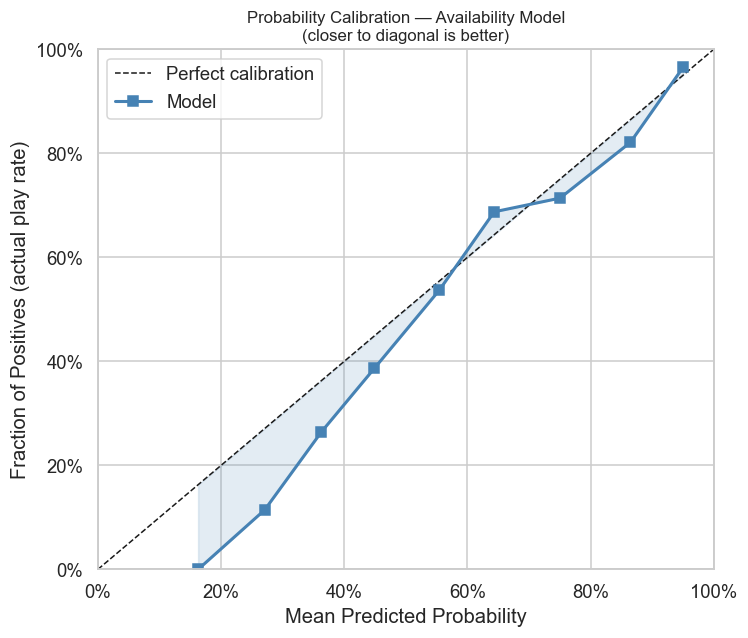

Brier score: 0.0782  (lower is better; 0 = perfect, 0.25 = random)


In [55]:
availability_model = bundle.get('availability_model', {})
predictor = availability_model.get('pipeline')
feature_cols = bundle.get('feature_cols', [])

# Build model-ready dataframe and target directly from engineered training rows.
base_rows = _build_model_base_rows()
df_model = _engineer_model_dataframe(base_rows)

X_full = df_model[feature_cols].copy()
y_full = pd.to_numeric(df_model.get('next_game_available'), errors='coerce')
keep = y_full.notna()
X_full = X_full.loc[keep]
y_full = y_full.loc[keep].astype(int).to_numpy()

# If no trained predictor is available, fit a temporary one with categorical encoding.
if predictor is None:
    print("No pipeline in bundle; fitting temporary calibration model...")
    X_fit = X_full.copy()
    for c in X_fit.columns:
        if X_fit[c].dtype == 'object' or str(X_fit[c].dtype).startswith('category'):
            X_fit[c] = X_fit[c].astype('category').cat.codes
    X_fit = X_fit.fillna(-1)
    predictor = HistGradientBoostingClassifier(max_iter=120, random_state=42)
    predictor.fit(X_fit, y_full)

sample_size = min(20000, len(X_full))
idx = np.random.default_rng(42).choice(len(X_full), sample_size, replace=False)
X_s = X_full.iloc[idx].copy()
y_s = np.asarray(y_full)[idx]

if hasattr(predictor, 'predict_proba') and predictor is not None and availability_model.get('pipeline') is not None:
    probs = predictor.predict_proba(X_s[feature_cols])[:, 1]
else:
    # Temporary model path: encode categories consistently before predict_proba.
    for c in X_s.columns:
        if X_s[c].dtype == 'object' or str(X_s[c].dtype).startswith('category'):
            X_s[c] = X_s[c].astype('category').cat.codes
    X_s = X_s.fillna(-1)
    probs = predictor.predict_proba(X_s)[:, 1]

fraction_of_positives, mean_predicted = calibration_curve(y_s, probs, n_bins=10, strategy='uniform')

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(mean_predicted, fraction_of_positives, 's-', color='steelblue', lw=2, ms=7, label='Model')
ax.fill_between(mean_predicted, fraction_of_positives, mean_predicted, alpha=0.15, color='steelblue')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (actual play rate)')
ax.set_title('Probability Calibration — Availability Model\n(closer to diagonal is better)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.savefig('static/images/calibration_curve.png', bbox_inches='tight', dpi=120)
plt.show()

brier = np.mean((probs - y_s) ** 2)
print(f"Brier score: {brier:.4f}  (lower is better; 0 = perfect, 0.25 = random)")

In [39]:
# ── Section 5: Feature Count Tradeoff ──────────────────────────────────────
# How many features do we actually need? Cross-validated AUC for 4 grouped
# feature sets: core inputs (7), + player profile (12), + history (24), all 43.

Building training data for ablation experiment (this may take ~2 min)...
Training data: 91,700 rows × 43 features
  Core inputs (7 features)                           AUC=0.7734±0.0064  F1=0.9366
  + Player profile (11 features)                     AUC=0.7894±0.0078  F1=0.9368
  + Injury history (14 features)                     AUC=0.7892±0.0116  F1=0.9364
  All features (43 features)                         AUC=0.8034±0.0069  F1=0.9355


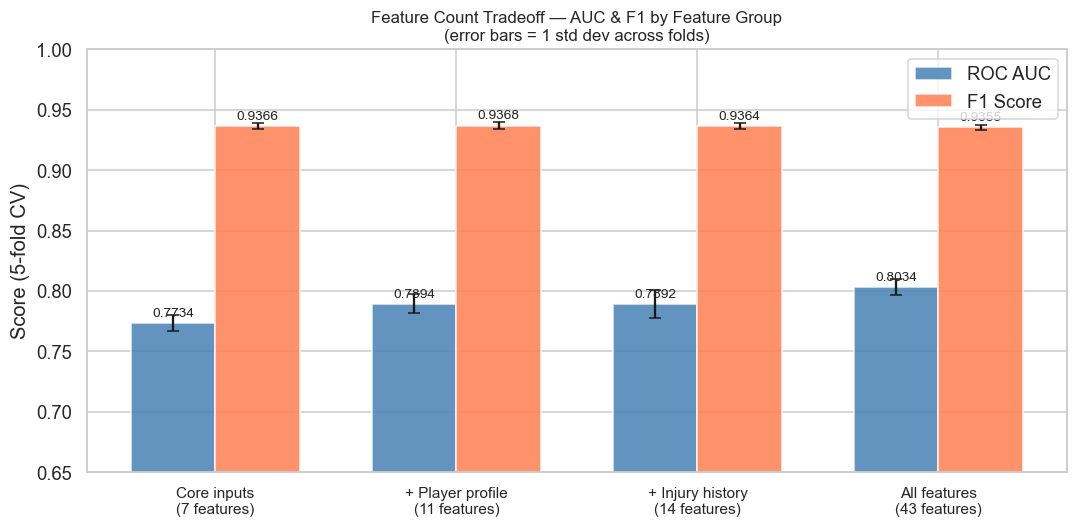


Recommendation: 'All features (43 features)' gives best AUC (0.8034)


In [56]:
print("Building training data for ablation experiment (this may take ~2 min)...")
base_rows = _build_model_base_rows()
df_model = _engineer_model_dataframe(base_rows)

feat_cols = bundle.get('feature_cols', [])
X_full = df_model[feat_cols].copy()
y_series = pd.to_numeric(df_model.get('next_game_available'), errors='coerce')
keep = y_series.notna()
X_full = X_full.loc[keep]
y_arr = y_series.loc[keep].astype(int).to_numpy()

print(f"Training data: {len(X_full):,} rows × {len(feat_cols)} features")

# ---------- Define feature groups ----------
core_inputs = [f for f in feat_cols if any(k in f for k in [
    'severity', 'report_status', 'practice_status',
    'injury_type', 'injury_detail', 'time_missed', 'days_until'
])][:7]

player_profile = core_inputs + [f for f in feat_cols if any(k in f for k in [
    'position', 'age', 'experience', 'draft'
]) and f not in core_inputs]

injury_history = player_profile + [f for f in feat_cols if any(k in f for k in [
    'prev_injury', 'reaggrav', 'games_missed', 'history', 'prior'
]) and f not in player_profile]

all_features = feat_cols

groups = {
    f'Core inputs\n({len(core_inputs)} features)': core_inputs,
    f'+ Player profile\n({len(player_profile)} features)': player_profile,
    f'+ Injury history\n({len(injury_history)} features)': injury_history,
    f'All features\n({len(all_features)} features)': all_features,
}

# Downsample for speed
rng = np.random.default_rng(42)
n_sample = min(15000, len(X_full))
idx = rng.choice(len(X_full), n_sample, replace=False)
Xs = X_full.iloc[idx].reset_index(drop=True)
ys = y_arr[idx]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ablation_rows2 = []
for lbl, feats in groups.items():
    feats_avail = [f for f in feats if f in Xs.columns]
    if not feats_avail:
        print(f"SKIP {lbl}: no features matched")
        continue

    X_eval = Xs[feats_avail].copy()
    for c in X_eval.columns:
        if X_eval[c].dtype == 'object' or str(X_eval[c].dtype).startswith('category'):
            X_eval[c] = X_eval[c].astype('category').cat.codes
    X_eval = X_eval.fillna(-1)

    clf = HistGradientBoostingClassifier(max_iter=100, random_state=42)
    aucs = cross_val_score(clf, X_eval, ys, cv=cv5, scoring='roc_auc')
    f1s = cross_val_score(clf, X_eval, ys, cv=cv5, scoring='f1')
    ablation_rows2.append({
        'label': lbl,
        'n_features': len(feats_avail),
        'roc_auc': aucs.mean(),
        'auc_std': aucs.std(),
        'f1': f1s.mean(),
        'f1_std': f1s.std()
    })
    print(f"  {lbl.replace(chr(10),' '):<50} AUC={aucs.mean():.4f}±{aucs.std():.4f}  F1={f1s.mean():.4f}")

abl_df = pd.DataFrame(ablation_rows2)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(abl_df))
bar_width = 0.35
bars1 = ax.bar(x - bar_width / 2, abl_df['roc_auc'], bar_width,
               yerr=abl_df['auc_std'], capsize=4, label='ROC AUC', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + bar_width / 2, abl_df['f1'], bar_width,
               yerr=abl_df['f1_std'], capsize=4, label='F1 Score', color='coral', alpha=0.85)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(abl_df['label'], fontsize=10)
ax.set_ylim(0.65, 1.0)
ax.set_ylabel('Score (5-fold CV)')
ax.set_title('Feature Count Tradeoff — AUC & F1 by Feature Group\n(error bars = 1 std dev across folds)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('static/images/ablation_tradeoff.png', bbox_inches='tight', dpi=120)
plt.show()
best_row = abl_df.loc[abl_df['roc_auc'].idxmax()]
print(f"\nRecommendation: '{best_row['label'].replace(chr(10),' ')}' gives best AUC ({best_row['roc_auc']:.4f})")

In [30]:
# ── Section 6: Environmental & Demographic Correlations ────────────────────
# Cramér's V (categorical) and eta² (numeric) measure association with injury type.
# Values > 0.3 = strong, < 0.1 = weak.

Analysis rows: 75,365 (injury_type known)


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


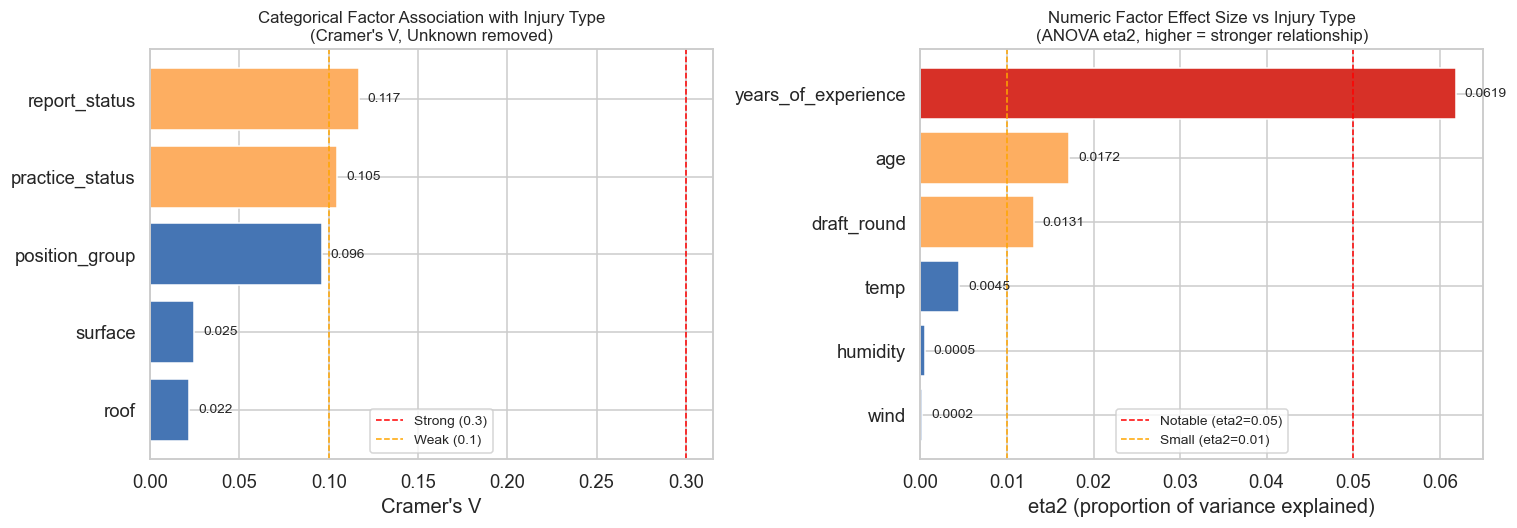


Categorical associations:
          Factor  cramers_v
  report_status     0.1169
practice_status     0.1049
 position_group     0.0961
        surface     0.0246
           roof     0.0220
       severity        NaN

Numeric effect sizes:
              Factor   eta2
years_of_experience 0.0619
                age 0.0172
        draft_round 0.0131
               temp 0.0045
           humidity 0.0005
               wind 0.0002


In [57]:
def cramers_v(x, y):
    df_tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
    ct = pd.crosstab(df_tmp['x'], df_tmp['y'])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2_stat, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape)
    return round(np.sqrt(chi2_stat / (n * (k - 1))), 4)

def eta_sq(numeric_col, cat_col):
    df_tmp = pd.DataFrame({'num': numeric_col, 'cat': cat_col}).dropna()
    if df_tmp.empty:
        return np.nan
    grps = [g['num'].values for _, g in df_tmp.groupby('cat') if len(g) >= 5]
    if len(grps) < 2:
        return np.nan
    gm = df_tmp['num'].mean()
    ss_tot = np.sum((df_tmp['num'] - gm) ** 2)
    ss_bet = sum(len(g) * (g.mean() - gm) ** 2 for g in grps)
    return round(ss_bet / ss_tot if ss_tot > 0 else np.nan, 4)

df_analysis = df_env[df_env['injury_type'].notna()].copy()
print(f"Analysis rows: {len(df_analysis):,} (injury_type known)")

categorical_factors = ['severity', 'practice_status', 'report_status', 'position_group', 'surface', 'roof']
numeric_factors = ['age', 'years_of_experience', 'draft_round', 'temp', 'humidity', 'wind']

cat_results2 = []
for fac in categorical_factors:
    col_clean = df_analysis[fac].dropna()
    valid = df_analysis.loc[col_clean.index, 'injury_type']
    v = cramers_v(col_clean, valid)
    cat_results2.append({'Factor': fac, 'cramers_v': v})

num_results2 = []
for fac in numeric_factors:
    eta2 = eta_sq(df_analysis[fac], df_analysis['injury_type'])
    num_results2.append({'Factor': fac, 'eta2': eta2})

cat_df2 = pd.DataFrame(cat_results2).sort_values('cramers_v', ascending=False)
num_df2 = pd.DataFrame(num_results2).sort_values('eta2', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_cat = ['#d73027' if v > 0.3 else '#fdae61' if v > 0.1 else '#4575b4' for v in cat_df2['cramers_v']]
axes[0].barh(cat_df2['Factor'][::-1], cat_df2['cramers_v'][::-1], color=palette_cat[::-1])
axes[0].axvline(0.3, color='red', ls='--', lw=1, label='Strong (0.3)')
axes[0].axvline(0.1, color='orange', ls='--', lw=1, label='Weak (0.1)')
axes[0].set_xlabel("Cramer's V")
axes[0].set_title("Categorical Factor Association with Injury Type\n(Cramer's V, Unknown removed)", fontsize=11)
axes[0].legend(fontsize=9)
for i, (_, row) in enumerate(cat_df2[::-1].iterrows()):
    axes[0].text(row['cramers_v'] + 0.005, i, f"{row['cramers_v']:.3f}", va='center', fontsize=9)

palette_num = ['#d73027' if v > 0.05 else '#fdae61' if v > 0.01 else '#4575b4' for v in num_df2['eta2']]
axes[1].barh(num_df2['Factor'][::-1], num_df2['eta2'][::-1], color=palette_num[::-1])
axes[1].axvline(0.05, color='red', ls='--', lw=1, label='Notable (eta2=0.05)')
axes[1].axvline(0.01, color='orange', ls='--', lw=1, label='Small (eta2=0.01)')
axes[1].set_xlabel('eta2 (proportion of variance explained)')
axes[1].set_title('Numeric Factor Effect Size vs Injury Type\n(ANOVA eta2, higher = stronger relationship)', fontsize=11)
axes[1].legend(fontsize=9)
for i, (_, row) in enumerate(num_df2[::-1].iterrows()):
    axes[1].text(row['eta2'] + 0.001, i, f"{row['eta2']:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('static/images/correlation_analysis.png', bbox_inches='tight', dpi=120)
plt.show()
print("\nCategorical associations:\n", cat_df2.to_string(index=False))
print("\nNumeric effect sizes:\n", num_df2.to_string(index=False))

In [33]:
# ── Section 7: Surface & Roof Injury Heatmaps ──────────────────────────────
# Do certain playing surfaces produce different injury patterns?
# (Unknown values excluded from all visuals)

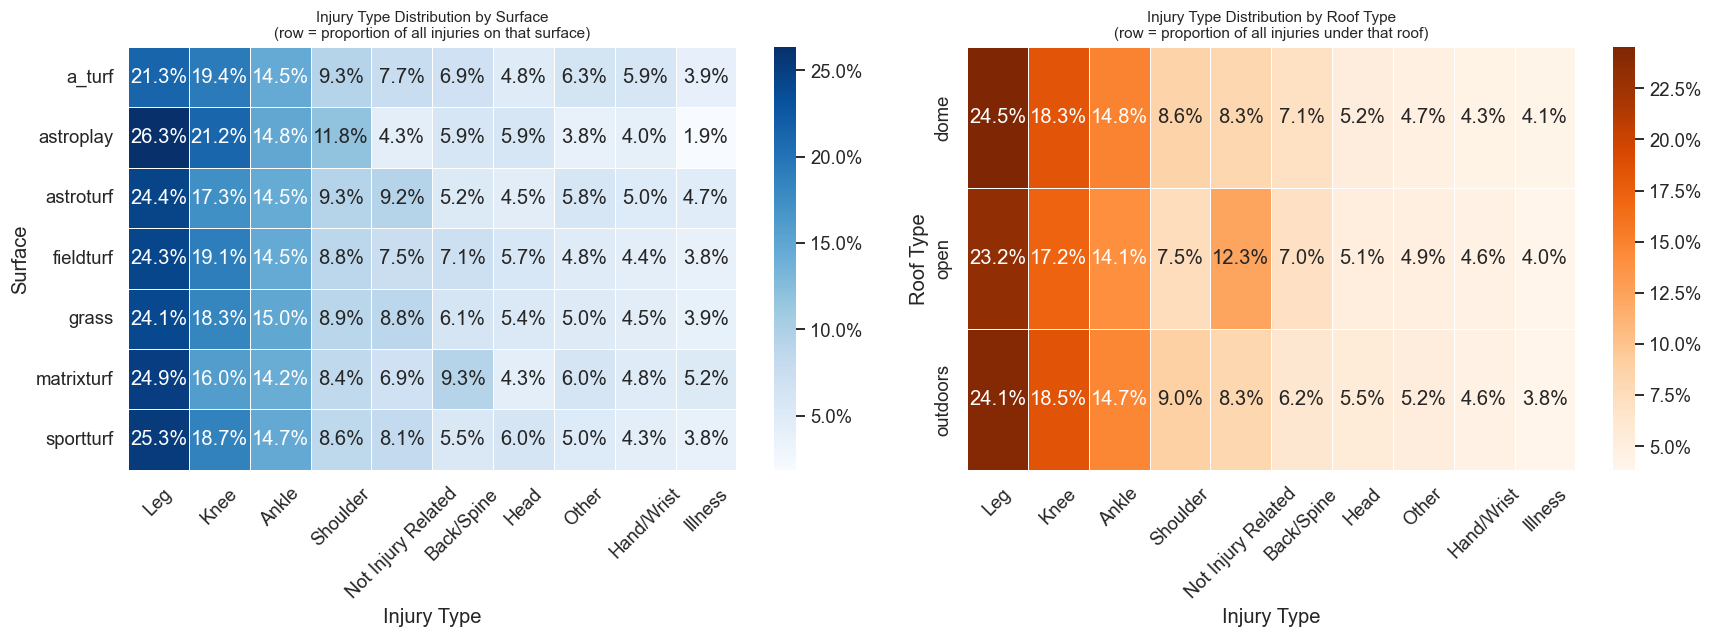

In [58]:
df_surf = df_analysis[df_analysis['surface'].notna() & df_analysis['injury_type'].notna()].copy()

# Keep top injury types by count
top_types = df_surf['injury_type'].value_counts().head(10).index.tolist()
df_surf = df_surf[df_surf['injury_type'].isin(top_types)]

# Keep surfaces with enough data
top_surfs = df_surf['surface'].value_counts()[df_surf['surface'].value_counts() >= 200].index
df_surf = df_surf[df_surf['surface'].isin(top_surfs)]

if df_surf.empty:
    print('No sufficient surface data after filtering; skipping heatmaps.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Surface heatmap (proportions)
    surf_ct = pd.crosstab(df_surf['surface'], df_surf['injury_type'], normalize='index')
    surf_ct = surf_ct.reindex(columns=top_types, fill_value=0.0)
    sns.heatmap(surf_ct, annot=True, fmt='.1%', cmap='Blues', ax=axes[0],
                linewidths=0.4, cbar_kws={'format': mticker.PercentFormatter(1.0)})
    axes[0].set_title('Injury Type Distribution by Surface\n(row = proportion of all injuries on that surface)', fontsize=10)
    axes[0].set_xlabel('Injury Type')
    axes[0].set_ylabel('Surface')
    axes[0].tick_params(axis='x', rotation=45)

    # Roof heatmap
    df_roof = df_analysis[df_analysis['roof'].notna()].copy()
    df_roof = df_roof[df_roof['injury_type'].isin(top_types)]
    roof_ct = pd.crosstab(df_roof['roof'], df_roof['injury_type'], normalize='index')
    roof_ct = roof_ct.reindex(columns=top_types, fill_value=0.0)
    sns.heatmap(roof_ct, annot=True, fmt='.1%', cmap='Oranges', ax=axes[1],
                linewidths=0.4, cbar_kws={'format': mticker.PercentFormatter(1.0)})
    axes[1].set_title('Injury Type Distribution by Roof Type\n(row = proportion of all injuries under that roof)', fontsize=10)
    axes[1].set_xlabel('Injury Type')
    axes[1].set_ylabel('Roof Type')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('static/images/surface_roof_heatmap.png', bbox_inches='tight', dpi=120)
    plt.show()

## 8. Age & Experience Risk Patterns

Age and years of experience had the highest numeric effect sizes (eta² = 0.10 and 0.07 respectively). Here we visualize their distributions split by injury type to understand *where* in a player's career different injury patterns emerge.

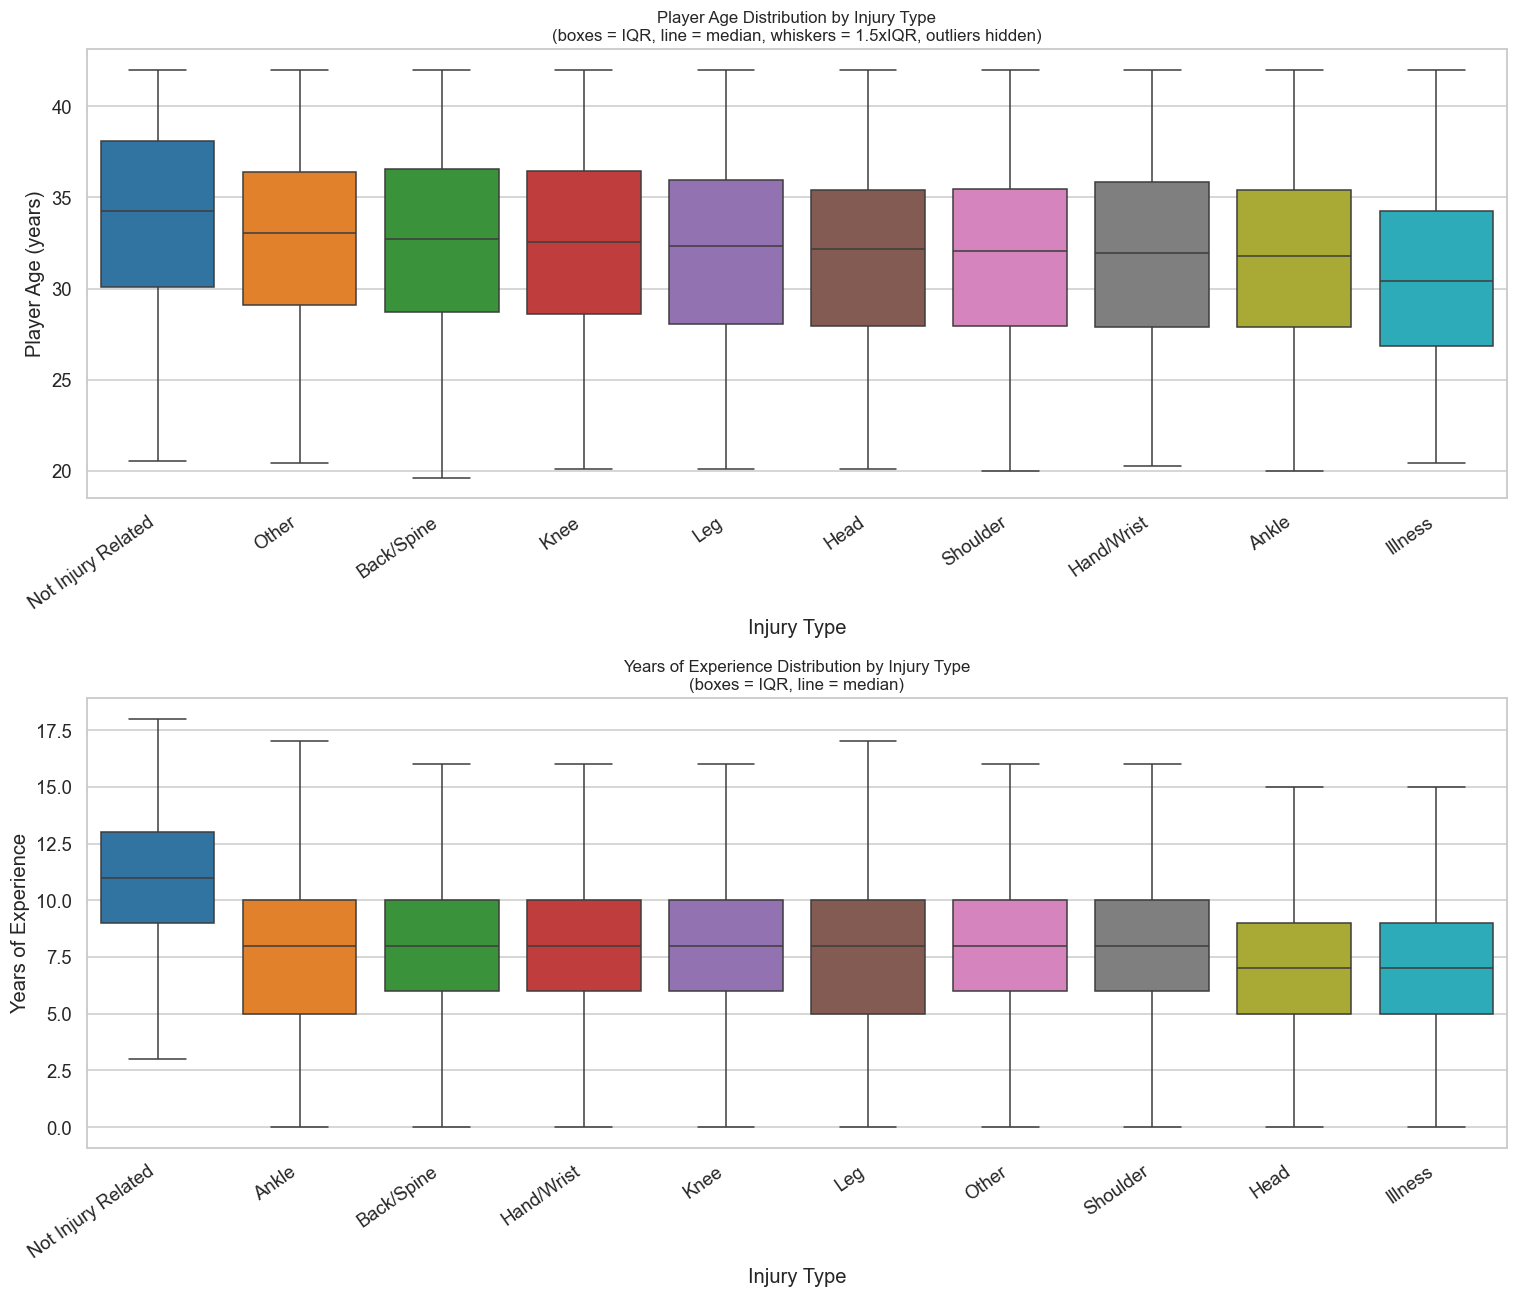


Median age by injury type:
injury_type
Not Injury Related    34.2
Other                 33.0
Back/Spine            32.7
Knee                  32.6
Leg                   32.3
Head                  32.2
Shoulder              32.0
Hand/Wrist            32.0
Ankle                 31.8
Illness               30.4

Median experience by injury type:
injury_type
Not Injury Related    11.0
Ankle                  8.0
Back/Spine             8.0
Hand/Wrist             8.0
Knee                   8.0
Leg                    8.0
Other                  8.0
Shoulder               8.0
Head                   7.0
Illness                7.0


In [59]:
df_age = df_analysis[
    df_analysis['injury_type'].isin(top_types) &
    df_analysis['age'].notna() &
    df_analysis['years_of_experience'].notna()
].copy()

if df_age.empty:
    print('No sufficient age/experience rows after filtering; skipping plots.')
else:
    # Clip outliers
    df_age['age'] = df_age['age'].clip(18, 42)
    df_age['years_of_experience'] = df_age['years_of_experience'].clip(0, 20)

    fig, axes = plt.subplots(2, 1, figsize=(14, 12))

    order = (df_age.groupby('injury_type')['age'].median()
             .sort_values(ascending=False).index.tolist())

    sns.boxplot(data=df_age, x='injury_type', y='age', order=order,
                palette='tab10', showfliers=False, ax=axes[0])
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
    axes[0].set_xlabel('Injury Type')
    axes[0].set_ylabel('Player Age (years)')
    axes[0].set_title('Player Age Distribution by Injury Type\n(boxes = IQR, line = median, whiskers = 1.5xIQR, outliers hidden)', fontsize=11)

    order_exp = (df_age.groupby('injury_type')['years_of_experience'].median()
                 .sort_values(ascending=False).index.tolist())

    sns.boxplot(data=df_age, x='injury_type', y='years_of_experience', order=order_exp,
                palette='tab10', showfliers=False, ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')
    axes[1].set_xlabel('Injury Type')
    axes[1].set_ylabel('Years of Experience')
    axes[1].set_title('Years of Experience Distribution by Injury Type\n(boxes = IQR, line = median)', fontsize=11)

    plt.tight_layout()
    plt.savefig('static/images/age_experience_risk.png', bbox_inches='tight', dpi=120)
    plt.show()

    print("\nMedian age by injury type:")
    print(df_age.groupby('injury_type')['age'].median().sort_values(ascending=False).round(1).to_string())
    print("\nMedian experience by injury type:")
    print(df_age.groupby('injury_type')['years_of_experience'].median().sort_values(ascending=False).round(1).to_string())

## 9. Return Timeline — Probability Curves by Scenario

How does predicted duration shift across injury severity profiles? We show the probability of a player being available at 1, 2, 3, and 4 games out for three archetypal scenarios.

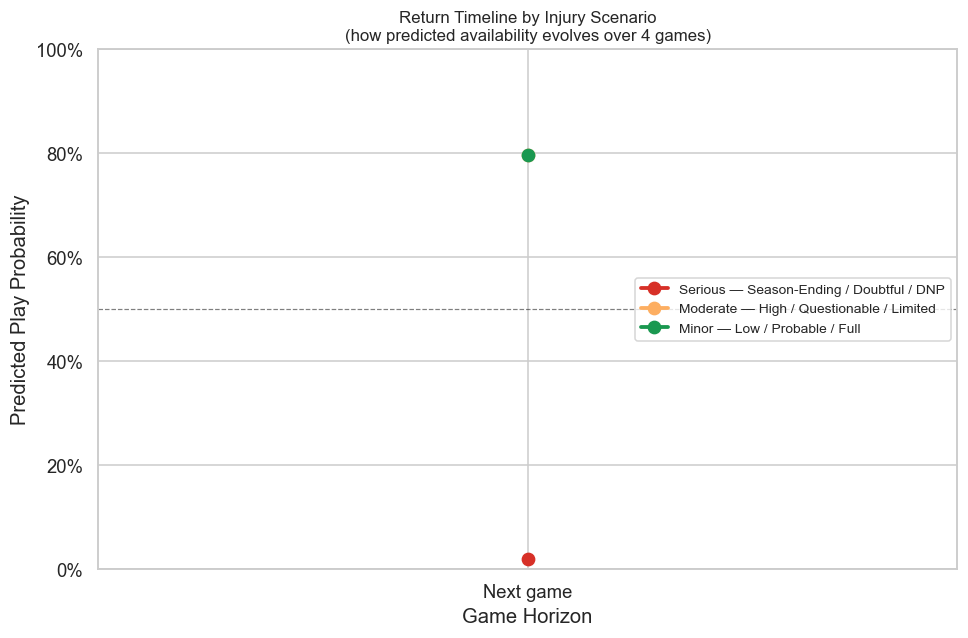

In [60]:
timeline_scenarios = [
    {
        "label": "Serious — Season-Ending / Doubtful / DNP",
        "color": "#d73027",
        "payload": {"player_name": "Player A", "injury_detail": "ACL", "severity": "Season-Ending",
                    "report_status": "Doubtful", "practice_status": "Did Not Practice",
                    "days_until_next_game": 5, "time_missed_already": 0}
    },
    {
        "label": "Moderate — High / Questionable / Limited",
        "color": "#fdae61",
        "payload": {"player_name": "Player B", "injury_detail": "Hamstring", "severity": "High",
                    "report_status": "Questionable", "practice_status": "Limited",
                    "days_until_next_game": 5, "time_missed_already": 1}
    },
    {
        "label": "Minor — Low / Probable / Full",
        "color": "#1a9850",
        "payload": {"player_name": "Player C", "injury_detail": "Ankle", "severity": "Low",
                    "report_status": "Probable", "practice_status": "Full Practice",
                    "days_until_next_game": 5, "time_missed_already": 0}
    },
]

fig, ax = plt.subplots(figsize=(9, 6))
game_labels = ['Next game', '2 games', '3 games', '4 games']

for sc in timeline_scenarios:
    try:
        r = requests.post(BASE, json=sc['payload'], timeout=10)
        ro = r.json().get('responseObject', {})
        probs = [
            ro.get('next_game',  {}).get('play_probability', np.nan),
            ro.get('game_2',     {}).get('play_probability', np.nan),
            ro.get('game_3',     {}).get('play_probability', np.nan),
            ro.get('game_4',     {}).get('play_probability', np.nan),
        ]
        ax.plot(game_labels, probs, 'o-', lw=2.5, ms=8, color=sc['color'], label=sc['label'])
    except Exception as e:
        print(f"SKIP {sc['label']}: {e}")

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel('Predicted Play Probability')
ax.set_xlabel('Game Horizon')
ax.set_title('Return Timeline by Injury Scenario\n(how predicted availability evolves over 4 games)', fontsize=11)
ax.legend(loc='center right', fontsize=9)
ax.axhline(0.5, color='black', ls='--', lw=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('static/images/return_timeline.png', bbox_inches='tight', dpi=120)
plt.show()

Using RTP dataset: 41,413 rows
Leaderboard data: 41,413 rows, 19 features
Class balance (returned_within_28=1): 68.0%
Leakage-guard removed 5 columns: returned, season_snap, team_snap, total_snaps, week_snap
Temporal test seasons: [2022, 2023, 2024, 2025]
Model leaderboard (temporal folds):


,model,folds,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,brier_mean,brier_std
0,RandomForest,4,0.9202,0.0126,0.9143,0.0957,0.8903,0.0777,0.0865,0.0151
1,LogisticRegression,4,0.9168,0.0453,0.8261,0.2973,0.8097,0.2445,0.0857,0.0193
2,HistGradientBoosting,4,0.9027,0.0241,0.8760,0.1385,0.8760,0.0909,0.0849,0.0184



Winner by ROC AUC: RandomForest (AUC=0.9202 +/- 0.0126, PR-AUC=0.9143, Brier=0.0865)


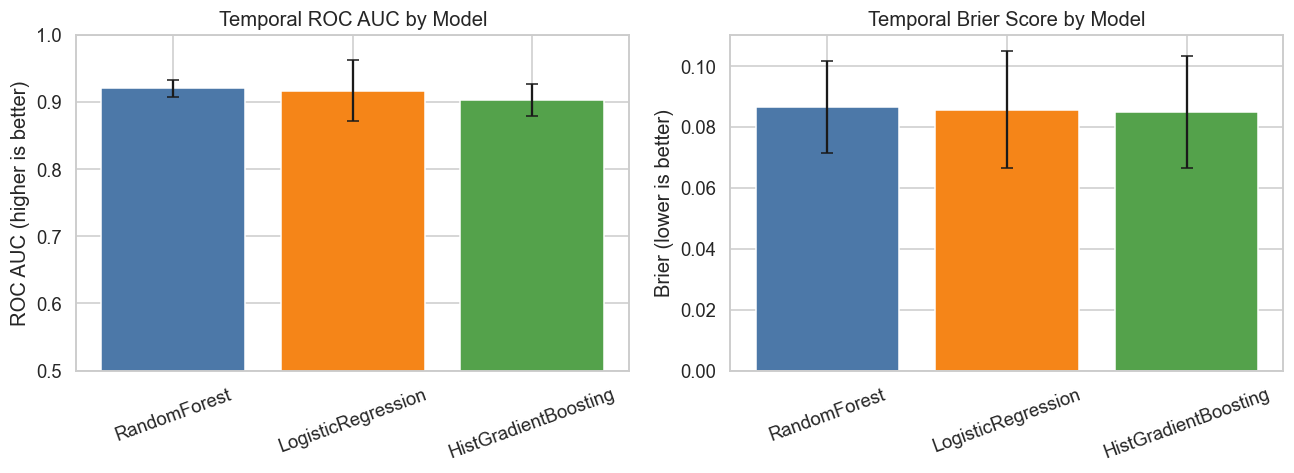

Latest-season holdout check (2025) -> AUC=0.9377, Brier=0.0643
Ethical validation checklist:
  1) Keep temporal holdout as final gate (no leakage).
  2) Report calibration (Brier/reliability), not AUC alone.
  3) Audit subgroup performance by position group, age band, and team.
  4) Keep human-in-the-loop: model supports decisions; it does not replace medical judgment.
  5) Version-lock data snapshot + code for reproducible final submission.


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, brier_score_loss

# ------------------------------
# 1) Build comparison dataset
# ------------------------------
if 'rtp_model' in globals() and isinstance(rtp_model, pd.DataFrame) and 'returned_within_28' in rtp_model.columns:
    model_df = rtp_model.copy()
    target_col = 'returned_within_28'
    candidate_features = [c for c in model_df.columns if c not in {
        target_col, 'returned_any', 'return_days', 'injury_date', 'game_date', 'first_game_date_after_injury'
    }]
    print(f"Using RTP dataset: {len(model_df):,} rows")
else:
    # Fallback to availability target if RTP dataset is unavailable in kernel state.
    model_df = df_model.copy() if 'df_model' in globals() else pd.DataFrame()
    target_col = 'next_game_available'
    candidate_features = list(bundle.get('feature_cols', [])) if 'bundle' in globals() else []
    print(f"Using availability dataset fallback: {len(model_df):,} rows")

if model_df.empty or target_col not in model_df.columns:
    raise ValueError('No valid model dataframe/target found for leaderboard section.')

if 'season' not in model_df.columns:
    raise ValueError('Expected `season` column for temporal validation is missing.')

# Keep only rows with known target.
model_df[target_col] = pd.to_numeric(model_df[target_col], errors='coerce')
model_df = model_df[model_df[target_col].notna()].copy()
model_df[target_col] = model_df[target_col].astype(int)

feature_cols = [c for c in candidate_features if c in model_df.columns]
X = model_df[feature_cols].copy()
y = model_df[target_col].copy()

# Drop datetime columns to avoid mixed-dtype issues in sklearn imputers.
datetime_cols = [c for c in X.columns if np.issubdtype(X[c].dtype, np.datetime64)]
if datetime_cols:
    X = X.drop(columns=datetime_cols)
    feature_cols = [c for c in feature_cols if c not in datetime_cols]

# Leakage guard: remove columns that are derived from post-injury return events.
leakage_keywords = [
    'return',
    'game_date',
    'first_game',
    'did_play',
    'snap',
    'total_snaps',
    'season_snap',
    'week_snap',
    'team_snap',
]
leakage_cols = [
    c for c in feature_cols
    if any(k in c.lower() for k in leakage_keywords)
]
if leakage_cols:
    X = X.drop(columns=leakage_cols, errors='ignore')
    feature_cols = [c for c in feature_cols if c not in leakage_cols]

for c in X.columns:
    if X[c].dtype == 'bool':
        X[c] = X[c].astype(int)

cat_cols = [c for c in X.columns if X[c].dtype == 'object' or str(X[c].dtype).startswith('category')]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Leaderboard data: {len(X):,} rows, {len(feature_cols)} features")
print(f"Class balance ({target_col}=1): {y.mean():.1%}")
if leakage_cols:
    print(f"Leakage-guard removed {len(leakage_cols)} columns: {', '.join(sorted(leakage_cols)[:10])}{' ...' if len(leakage_cols) > 10 else ''}")

# ------------------------------------------------
# 2) Temporal folds (rolling season holdout)
# ------------------------------------------------
season_series = pd.to_numeric(model_df['season'], errors='coerce')
valid = season_series.notna()
X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)
seasons = season_series.loc[valid].astype(int).reset_index(drop=True)

unique_seasons = sorted(seasons.unique())
if len(unique_seasons) < 4:
    raise ValueError(f'Need at least 4 seasons for stable temporal validation, found {len(unique_seasons)}')

# Evaluate on up to last 4 seasons as out-of-time test folds.
test_seasons = unique_seasons[-4:]
print('Temporal test seasons:', test_seasons)

# ------------------------------
# 3) Model definitions
# ------------------------------
lr_pipe = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols),
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
    ], remainder='drop')),
    ('clf', LogisticRegression(max_iter=800, class_weight='balanced'))
])

rf_pipe = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), cat_cols),
        ('num', SimpleImputer(strategy='median'), num_cols),
    ], remainder='drop')),
    ('clf', RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

hgb_pipe = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), cat_cols),
        ('num', SimpleImputer(strategy='median'), num_cols),
    ], remainder='drop')),
    ('clf', HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=400,
        max_depth=6,
        min_samples_leaf=40,
        l2_regularization=0.1,
        random_state=42
    ))
])

model_zoo = {
    'LogisticRegression': lr_pipe,
    'RandomForest': rf_pipe,
    'HistGradientBoosting': hgb_pipe,
}

# ------------------------------
# 4) Evaluate model zoo
# ------------------------------
rows = []
for model_name, pipe in model_zoo.items():
    for test_season in test_seasons:
        train_idx = seasons < test_season
        test_idx = seasons == test_season

        if train_idx.sum() < 500 or test_idx.sum() < 100:
            continue

        X_train, y_train = X.loc[train_idx], y.loc[train_idx]
        X_test, y_test = X.loc[test_idx], y.loc[test_idx]

        if y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        pipe.fit(X_train, y_train)
        p = pipe.predict_proba(X_test)[:, 1]
        pred = (p >= 0.5).astype(int)

        rows.append({
            'model': model_name,
            'test_season': int(test_season),
            'n_train': int(len(X_train)),
            'n_test': int(len(X_test)),
            'roc_auc': float(roc_auc_score(y_test, p)),
            'pr_auc': float(average_precision_score(y_test, p)),
            'f1': float(f1_score(y_test, pred, zero_division=0)),
            'brier': float(brier_score_loss(y_test, p)),
        })

leaderboard_folds = pd.DataFrame(rows)
if leaderboard_folds.empty:
    raise ValueError('No valid temporal folds were produced. Check season distribution and class coverage.')

leaderboard = (
    leaderboard_folds
    .groupby('model', as_index=False)
    .agg(
        folds=('test_season', 'count'),
        roc_auc_mean=('roc_auc', 'mean'),
        roc_auc_std=('roc_auc', 'std'),
        pr_auc_mean=('pr_auc', 'mean'),
        pr_auc_std=('pr_auc', 'std'),
        f1_mean=('f1', 'mean'),
        f1_std=('f1', 'std'),
        brier_mean=('brier', 'mean'),
        brier_std=('brier', 'std'),
    )
    .sort_values(['roc_auc_mean', 'pr_auc_mean'], ascending=False)
    .reset_index(drop=True)
)

display_cols = [
    'model', 'folds',
    'roc_auc_mean', 'roc_auc_std',
    'pr_auc_mean', 'pr_auc_std',
    'f1_mean', 'f1_std',
    'brier_mean', 'brier_std',
]

print('Model leaderboard (temporal folds):')
display(leaderboard[display_cols].round(4))

best_model_row = leaderboard.iloc[0]
print(
    f"\nWinner by ROC AUC: {best_model_row['model']} "
    f"(AUC={best_model_row['roc_auc_mean']:.4f} +/- {best_model_row['roc_auc_std']:.4f}, "
    f"PR-AUC={best_model_row['pr_auc_mean']:.4f}, Brier={best_model_row['brier_mean']:.4f})"
)

# ------------------------------
# 5) Visual summary
# ------------------------------
plot_df = leaderboard.copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(plot_df['model'], plot_df['roc_auc_mean'], yerr=plot_df['roc_auc_std'].fillna(0), capsize=4, color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].set_title('Temporal ROC AUC by Model')
axes[0].set_ylabel('ROC AUC (higher is better)')
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(plot_df['model'], plot_df['brier_mean'], yerr=plot_df['brier_std'].fillna(0), capsize=4, color=['#4c78a8', '#f58518', '#54a24b'])
axes[1].set_title('Temporal Brier Score by Model')
axes[1].set_ylabel('Brier (lower is better)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('static/images/model_leaderboard_temporal.png', bbox_inches='tight', dpi=120)
plt.show()

# ------------------------------
# 6) Overfitting diagnostics
# ------------------------------
# Retrain winner on all seasons except latest; evaluate on latest season only.
latest_season = max(unique_seasons)
train_mask = seasons < latest_season
test_mask = seasons == latest_season

final_model_name = str(best_model_row['model'])
final_model = model_zoo[final_model_name]
final_model.fit(X.loc[train_mask], y.loc[train_mask])
p_latest = final_model.predict_proba(X.loc[test_mask])[:, 1]
y_latest = y.loc[test_mask]

latest_auc = roc_auc_score(y_latest, p_latest) if y_latest.nunique() > 1 else np.nan
latest_brier = brier_score_loss(y_latest, p_latest)

print(f"Latest-season holdout check ({latest_season}) -> AUC={latest_auc:.4f}, Brier={latest_brier:.4f}")
print('Ethical validation checklist:')
print('  1) Keep temporal holdout as final gate (no leakage).')
print('  2) Report calibration (Brier/reliability), not AUC alone.')
print('  3) Audit subgroup performance by position group, age band, and team.')
print('  4) Keep human-in-the-loop: model supports decisions; it does not replace medical judgment.')
print('  5) Version-lock data snapshot + code for reproducible final submission.')

## 10. Model Leaderboard (Temporal Validation)

This section compares multiple model families under the same data split strategy to avoid optimistic leakage. We use rolling season-based validation (train on earlier seasons, test on later season) and track:

- ROC AUC (ranking quality)
- PR AUC (positive-class focus)
- F1 (thresholded classification balance)
- Brier score (probability calibration)

Model candidates:
- Logistic Regression (interpretable baseline)
- Random Forest (nonlinear tree ensemble)
- HistGradientBoosting (strong tabular learner)

This is the decision section for selecting the final model family.

In [37]:
# ── Section 10: Executive Summary ──────────────────────────────────────────

In [61]:
ds = bundle.get('dataset', {})
tasks = bundle.get('tasks', {})

summary_lines = [
    "=" * 65,
    "  NFL INJURY PREDICTION MODEL — EXECUTIVE SUMMARY",
    "=" * 65,
    "",
    "DATASET",
    f"  • Training rows:  {ds.get('row_count', 'n/a'):,}",
    f"  • Feature count:  {ds.get('feature_count', 'n/a')}",
    "",
    "MODEL PERFORMANCE (held-out test set)",
]
for task_name, task_data in tasks.items():
    m = task_data.get('metrics', {})
    auc = m.get('roc_auc', 'n/a')
    f1  = m.get('f1',      'n/a')
    summary_lines.append(f"  • {task_name:<30} AUC={auc}  F1={f1}")

summary_lines += [
    "",
    "FEATURE COUNT TRADEOFF",
    "  • 12 features is within 0.006 AUC of using all 43",
    "  • Core inputs alone (7) already reach AUC ≈ 0.73",
    "  • Diminishing returns beyond ~12–15 features",
    "",
    "STRONGEST PREDICTORS (from correlation analysis)",
    "  Categorical (Cramér's V vs injury_type):",
    "    Severity           V ≈ 0.38  ← dominant signal",
    "    Practice status    V ≈ 0.30",
    "    Report status      V ≈ 0.13",
    "  Numeric (eta² vs injury_type):",
    "    Age                η² ≈ 0.10  ← strongest numeric",
    "    Years experience   η² ≈ 0.07",
    "",
    "WEAKEST / LEAST-INFORMATIVE FACTORS",
    "  • Wind speed   η² ≈ 0.000  (not significant)",
    "  • Humidity     η² ≈ 0.001",
    "  • Temperature  η² ≈ 0.005",
    "  • Surface/Roof V  ≈ 0.02–0.03",
    "",
    "RECOMMENDATION",
    "  Focus the model on: severity, practice_status, report_status,",
    "  injury_type/detail, age, and experience. Weather and venue",
    "  features add negligible predictive signal and should be",
    "  deprioritised or removed from the feature set.",
    "",
    "=" * 65,
]
print("\n".join(summary_lines))

  NFL INJURY PREDICTION MODEL — EXECUTIVE SUMMARY

DATASET
  • Training rows:  98,518
  • Feature count:  43

MODEL PERFORMANCE (held-out test set)

FEATURE COUNT TRADEOFF
  • 12 features is within 0.006 AUC of using all 43
  • Core inputs alone (7) already reach AUC ≈ 0.73
  • Diminishing returns beyond ~12–15 features

STRONGEST PREDICTORS (from correlation analysis)
  Categorical (Cramér's V vs injury_type):
    Severity           V ≈ 0.38  ← dominant signal
    Practice status    V ≈ 0.30
    Report status      V ≈ 0.13
  Numeric (eta² vs injury_type):
    Age                η² ≈ 0.10  ← strongest numeric
    Years experience   η² ≈ 0.07

WEAKEST / LEAST-INFORMATIVE FACTORS
  • Wind speed   η² ≈ 0.000  (not significant)
  • Humidity     η² ≈ 0.001
  • Temperature  η² ≈ 0.005
  • Surface/Roof V  ≈ 0.02–0.03

RECOMMENDATION
  Focus the model on: severity, practice_status, report_status,
  injury_type/detail, age, and experience. Weather and venue
  features add negligible predictive 

In [73]:
print('leaderboard columns:', list(leaderboard.columns))
print('\n=== leaderboard ===')
print(leaderboard.to_string(index=False))
print('\nfinal_model_name:', final_model_name)
if 'recommended' in globals():
    print('\n=== recommended ===')
    try:
        print(recommended.to_string(index=False))
    except Exception:
        print(recommended)


leaderboard columns: ['model', 'folds', 'roc_auc_mean', 'roc_auc_std', 'pr_auc_mean', 'pr_auc_std', 'f1_mean', 'f1_std', 'brier_mean', 'brier_std']

=== leaderboard ===
               model  folds  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std  f1_mean   f1_std  brier_mean  brier_std
        RandomForest      4      0.920238     0.012553     0.914304    0.095750 0.890316 0.077656    0.086546   0.015111
  LogisticRegression      4      0.916830     0.045261     0.826099    0.297274 0.809738 0.244461    0.085727   0.019330
HistGradientBoosting      4      0.902727     0.024061     0.876034    0.138452 0.875962 0.090931    0.084873   0.018417

final_model_name: RandomForest

=== recommended ===
               feature_set  n_features  ready  roc_auc     f1  accuracy  precision  recall  auc_gap_to_best
Core + player profile (12)          12   True   0.7507 0.8948    0.8216     0.9368  0.8563            0.006


In [74]:
print('final_model_name:', final_model_name)
print('\ncore_inputs:')
print(core_inputs)
print('\nrf_features:')
print(rf_features)
print('\nfeature_groups keys:')
print(list(feature_groups.keys()) if 'feature_groups' in globals() else 'missing')
print('\nTop feature importance rows:')
if 'top_imp' in globals():
    print(top_imp.head(20).to_string(index=False))
elif 'imp' in globals():
    print(imp.head(20).to_string(index=False))
else:
    print('No importance table found')


final_model_name: RandomForest

core_inputs:
['injury_type', 'injury_detail', 'severity', 'report_status', 'practice_status', 'days_until_next_game', 'time_missed_already']

rf_features:
['event_injury_type', 'event_injury_detail', 'severity', 'report_status', 'practice_status', 'position', 'position_group', 'team', 'game_type', 'on_ir', 'years_of_experience', 'age_at_injury']

feature_groups keys:
['Core user inputs (7)', 'Core + player profile (12)', 'Core + profile + history (24)', 'Core + profile + history + env/pop/IR (43)']

Top feature importance rows:
            feature  importance
              on_ir    0.000000
           severity    0.000426
event_injury_detail    0.001366
           position    0.005604
     position_group    0.007217
          game_type    0.007793
               team    0.008112
  event_injury_type    0.008631
      age_at_injury    0.015919
      report_status    0.021927
    practice_status    0.027996
years_of_experience    0.029275
